In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
nav = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/nav_history_clean.csv")

In [5]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [7]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [8]:
nav["date"] = pd.to_datetime(nav["date"])

In [9]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [10]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [11]:
nav.head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


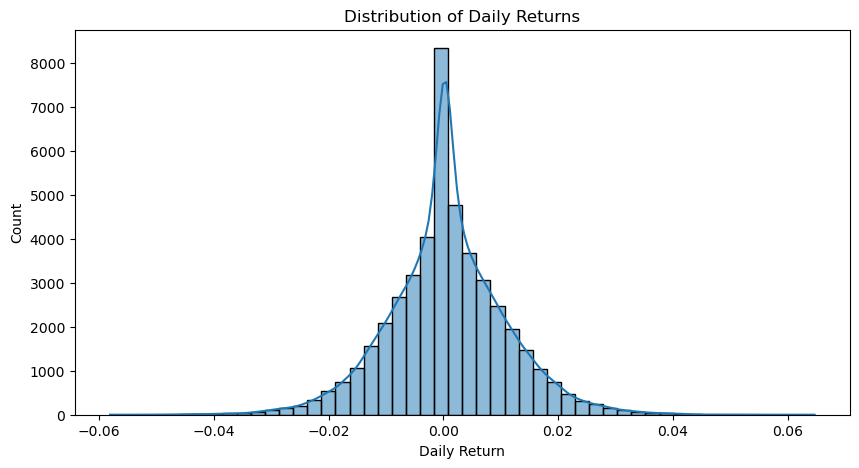

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.show()

In [13]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [4]:
import pandas as pd
import numpy as np

nav = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/nav_history_clean.csv")
nav["date"] = pd.to_datetime(nav["date"])


In [5]:
nav = nav.sort_values(["amfi_code", "date"])

In [19]:
cagr_results = []

In [20]:
for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].sort_values("date")

    latest_date = fund_data["date"].max()

In [21]:
    latest_nav = fund_data.iloc[-1]["nav"]

In [22]:
    def calculate_cagr(years):

        start_date = latest_date - pd.DateOffset(years=years)

        data = fund_data[fund_data["date"] >= start_date]

        if len(data) < 2:
            return np.nan

        start_nav = data.iloc[0]["nav"]

        cagr = (latest_nav / start_nav) ** (1 / years) - 1

        return cagr

In [23]:
    cagr_results.append({

        "amfi_code": fund,

        "CAGR_1Y": calculate_cagr(1),

        "CAGR_3Y": calculate_cagr(3),

        "CAGR_5Y": calculate_cagr(5)

    })

In [25]:
cagr_df = pd.DataFrame(cagr_results)

In [26]:
cagr_df["CAGR_1Y"] *= 100
cagr_df["CAGR_3Y"] *= 100
cagr_df["CAGR_5Y"] *= 100

In [27]:
cagr_df = cagr_df.round(2)

In [28]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,149324,65.14,27.0,27.92


In [29]:
cagr_df = cagr_df.sort_values(
    by="CAGR_3Y",
    ascending=False
)

In [31]:
cagr_df.to_csv(
    "C:/Users/soham/MutualFundProject/data/processed/cagr_comparison.csv",
    index=False
)

In [32]:
print(cagr_df.describe())

       amfi_code  CAGR_1Y  CAGR_3Y  CAGR_5Y
count        1.0     1.00      1.0     1.00
mean    149324.0    65.14     27.0    27.92
std          NaN      NaN      NaN      NaN
min     149324.0    65.14     27.0    27.92
25%     149324.0    65.14     27.0    27.92
50%     149324.0    65.14     27.0    27.92
75%     149324.0    65.14     27.0    27.92
max     149324.0    65.14     27.0    27.92


#### Task 3

In [34]:
nav = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/nav_history_clean.csv")
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

In [35]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [36]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [37]:
sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    returns = fund_data["daily_return"].dropna()

    if len(returns) > 1:

        mean_return = returns.mean()
        std_return = returns.std()

        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    else:

        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": fund,
        "Sharpe_Ratio": round(sharpe, 4)
    })

In [38]:
sharpe_df = pd.DataFrame(sharpe_results)

In [39]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

In [40]:
print(sharpe_df.head())

    amfi_code  Sharpe_Ratio
34     148567        1.4483
30     120843        1.3067
36     148569        1.2349
19     119551        1.2083
25     120505        1.1801


In [42]:
sharpe_df.to_csv(
    "C:/Users/soham/MutualFundProject/data/processed/sharpe_ratio.csv",
    index=False
)

#### Task 4

In [44]:
import pandas as pd
import numpy as np

nav = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [45]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [46]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [47]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    returns = fund_data["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    if len(downside_returns) > 1:

        mean_return = returns.mean()

        downside_std = downside_returns.std()

        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    else:

        sortino = np.nan

    sortino_results.append({
        "amfi_code": fund,
        "Sortino_Ratio": round(sortino, 4)
    })

In [48]:
sortino_df = pd.DataFrame(sortino_results)

In [49]:
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

In [50]:
print(sortino_df.head())

    amfi_code  Sortino_Ratio
34     148567         2.3856
30     120843         2.3643
36     148569         2.1469
19     119551         2.1403
25     120505         2.0294


In [51]:
sortino_df.to_csv(
    "C:/Users/soham/MutualFundProject/data/processed/sortino_ratio.csv",
    index=False
)

#### Task 5

In [53]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

In [55]:
nav = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/nav_history_clean.csv")
benchmark = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/benchmark_indices_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [57]:
nav = nav.sort_values(["amfi_code", "date"])

nav["fund_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

In [58]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    merged = pd.merge(
        fund_data,
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

In [59]:
    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["fund_return"]
        )

        beta = slope
        alpha = intercept * 252

    else:

        alpha = np.nan
        beta = np.nan

    alpha_beta.append({
        "amfi_code": fund,
        "Alpha": round(alpha, 4),
        "Beta": round(beta, 4)
    })

In [60]:
alpha_beta_df = pd.DataFrame(alpha_beta)

In [61]:
print(alpha_beta_df.head())

   amfi_code   Alpha  Beta
0     149324  0.3064  -0.0


In [62]:
alpha_beta_df.to_csv(
    "C:/Users/soham/MutualFundProject/data/processed/alpha_beta.csv",
    index=False
)

In [63]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')


#### Task 6

In [64]:
nav = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [65]:
mdd_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].copy()

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (
        fund_data["nav"] / fund_data["running_max"]
    ) - 1

    max_dd = fund_data["drawdown"].min()

    worst_date = fund_data.loc[
        fund_data["drawdown"].idxmin(),
        "date"
    ]

    mdd_results.append({
        "amfi_code": fund,
        "Max_Drawdown": round(max_dd * 100, 2),
        "Worst_Date": worst_date
    })

In [66]:
mdd_df = pd.DataFrame(mdd_results)

In [67]:
mdd_df = mdd_df.sort_values(
    by="Max_Drawdown"
)

In [68]:
print(mdd_df.head())

    amfi_code  Max_Drawdown Worst_Date
22     119599        -52.57 2025-10-28
17     119095        -51.68 2026-05-11
4      101207        -35.45 2026-05-11
39     149324        -31.17 2025-01-03
21     119598        -28.71 2025-05-14


In [69]:
mdd_df.to_csv(
    "C:/Users/soham/MutualFundProject/data/processed/max_drawdown.csv",
    index=False
)

#### Task 7

In [73]:
import pandas as pd

cagr = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/cagr_comparison.csv")
sharpe = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/sharpe_ratio.csv")
alpha = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/alpha_beta.csv")
mdd = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/max_drawdown.csv")
fund = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/fund_master_clean.csv")

In [76]:
scorecard = cagr.merge(sharpe, on="amfi_code")
scorecard = scorecard.merge(alpha, on="amfi_code")
scorecard = scorecard.merge(mdd, on="amfi_code")
scorecard = scorecard.merge(
    fund[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

In [78]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(ascending=True)

In [79]:
scorecard["Fund_Score"] = (

    30 * (1 / scorecard["Return_Rank"])

    + 25 * (1 / scorecard["Sharpe_Rank"])

    + 20 * (1 / scorecard["Alpha_Rank"])

    + 15 * (1 / scorecard["Expense_Rank"])

    + 10 * (1 / scorecard["Drawdown_Rank"])

)

In [80]:
scorecard["Fund_Score"] = (

    scorecard["Fund_Score"]

    / scorecard["Fund_Score"].max()

) * 100

In [81]:
scorecard["Fund_Score"] = scorecard["Fund_Score"].round(2)

In [82]:
scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
)

In [83]:
print(scorecard.head(10))

   amfi_code  CAGR_1Y  CAGR_3Y  CAGR_5Y  Sharpe_Ratio   Alpha  Beta  \
0     149324    65.14     27.0    27.92        0.9498  0.3064  -0.0   

   Max_Drawdown  Worst_Date  expense_ratio_pct  Return_Rank  Sharpe_Rank  \
0        -31.17  2025-01-03               1.52          1.0          1.0   

   Alpha_Rank  Expense_Rank  Drawdown_Rank  Fund_Score  
0         1.0           1.0            1.0       100.0  


In [84]:
scorecard.to_csv(
    "C:/Users/soham/MutualFundProject/data/processed/fund_scorecard.csv",
    index=False
)

#### Task 8

In [85]:
nav = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/nav_history_clean.csv")
benchmark = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/benchmark_indices_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [86]:
scorecard = pd.read_csv("C:/Users/soham/MutualFundProject/data/processed/fund_scorecard.csv")

top5 = scorecard.head(5)["amfi_code"].tolist()

In [87]:
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav = nav[nav["date"] >= start_date]

benchmark = benchmark[benchmark["date"] >= start_date]

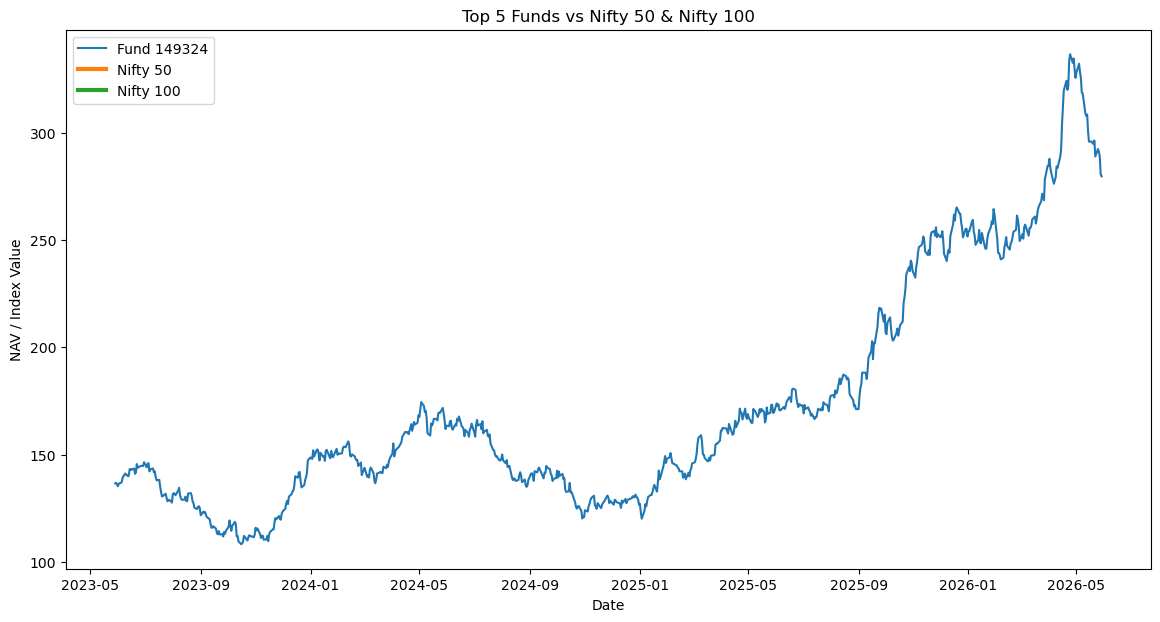

In [89]:
# Separate Nifty 50 and Nifty 100
nifty50 = benchmark[benchmark["index_name"] == "Nifty 50"]
nifty100 = benchmark[benchmark["index_name"] == "Nifty 100"]

plt.figure(figsize=(14,7))

# Plot Top 5 Funds
for fund in top5:
    temp = nav[nav["amfi_code"] == fund]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=f"Fund {fund}"
    )

# Plot Nifty 50
plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    linewidth=3,
    label="Nifty 50"
)

# Plot Nifty 100
plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="Nifty 100"
)

plt.title("Top 5 Funds vs Nifty 50 & Nifty 100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()

plt.savefig("benchmark_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [91]:
# Keep only Nifty 100 data
nifty100 = benchmark[benchmark["index_name"] == "Nifty 100"].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Calculate benchmark returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

tracking_error = []

for fund in top5:

    temp = nav[nav["amfi_code"] == fund].copy()

    temp = temp.sort_values("date")

    temp["fund_return"] = temp["nav"].pct_change()

    merged = pd.merge(
        temp,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    te = (merged["fund_return"] - merged["benchmark_return"]).std() * np.sqrt(252)

    tracking_error.append({
        "amfi_code": fund,
        "Tracking_Error": round(te, 4)
    })

tracking_error_df = pd.DataFrame(tracking_error)

print(tracking_error_df)

   amfi_code  Tracking_Error
0     149324             NaN


In [93]:
tracking_error_df.to_csv(
    "C:/Users/soham/MutualFundProject/data/processed/tracking_error.csv",
    index=False
)